In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/florida_bridge_with_risk_final.csv")

In [3]:
df.head()

,STRUCTURE_NUMBER_008,ROUTE_PREFIX_005B,SERVICE_LEVEL_005C,ROUTE_NUMBER_005D,DIRECTION_005E,HIGHWAY_DISTRICT_002,COUNTY_CODE_003,PLACE_CODE_004,FEATURES_DESC_006A,FACILITY_CARRIED_007,...,PIER_PROTECTION_111,SCOUR_CRITICAL_113,FUTURE_ADT_114,YEAR_OF_FUTURE_ADT_115,MIN_NAV_CLR_MT_116,BRIDGE_CONDITION,LOWEST_RATING,DECK_AREA,MIN_CONDITION,Infrastructure_Risk
0,10001,2,1,00041,0,1,15,0,'CRESTWOOD WATERWAY','US-41 (SR-45)',...,NaN,8,52050,2043,0.0,NaN,7,191.80,7.0,Low
1,10003,4,1,00074,0,1,15,0,'MYRTLE SLOUGH','CR-74',...,NaN,8,9196,2042,0.0,NaN,6,113.36,6.0,Medium
2,10006,4,2,0765A,0,1,15,0,'N FORK ALLIGATOR CREEK','CR765A (TAYLOR RD)',...,NaN,8,9890,2042,0.0,NaN,7,69.58,7.0,Low
3,10007,4,1,00764,0,1,15,0,'MYRTLE SLOUGH','CR-764',...,NaN,8,3593,2042,0.0,NaN,6,356.46,6.0,Medium
4,10008,4,1,00764,0,1,15,0,'SHELL CREEK','CR-764',...,NaN,8,1509,2042,0.0,NaN,6,385.52,6.0,Medium


In [11]:
drop_cols = [
    "STRUCTURE_NUMBER_008",
    "COUNTY_CODE_003",
    "PLACE_CODE_004",
    "FEATURES_DESC_006A",
    "FACILITY_CARRIED_007",
    "LOCATION_009",
    "BASE_HWY_NETWORK_012",
    "LRS_INV_ROUTE_013A",
    "SUBROUTE_NO_013B",

    "DECK_COND_058",
    "SUPERSTRUCTURE_COND_059",
    "SUBSTRUCTURE_COND_060",
    "CHANNEL_COND_061",
    "CULVERT_COND_062",
    "BRIDGE_CONDITION",
    "LOWEST_RATING",
    "MIN_CONDITION",
    "OPERATING_RATING_064",
    "INVENTORY_RATING_066",
    "STRUCTURAL_EVAL_067",
    "DECK_GEOMETRY_EVAL_068",
    "UNDCLRENCE_EVAL_069",
    "POSTING_EVAL_070",
    "WATERWAY_EVAL_071",
    "APPR_ROAD_EVAL_072",


    "WORK_PROPOSED_075A",
    "WORK_DONE_BY_075B",


    "RECORD_TYPE_005A",
    "STATE_CODE_001",
    "HIGHWAY_SYSTEM_104",
    "FEDERAL_LANDS_105",
    "NATIONAL_NETWORK_110",
    "OWNER_022",
    "YEAR_ADT_030",
    "YEAR_OF_IMP_097",
    
    "ROUTE_PREFIX_005B",
    "ROUTE_NUMBER_005D",
    "DIRECTION_005E",
    "SERVICE_ON_042A",
    "SERVICE_UND_042B",
    "STRUCTURE_KIND_043A",
    "STRUCTURE_TYPE_043B",
"LAT_UND_REF_055A",
"LAT_UND_MT_055B",
"LEFT_LAT_UND_MT_056"

]

df = df.drop(columns=drop_cols, errors="ignore")

print("New Shape:", df.shape)

New Shape: (3417, 72)


In [13]:
for col in df.columns:
    if df[col].nunique() > 3000:
        print(col, df[col].nunique())

LAT_016 3356
LONG_017 3363


In [16]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(constant_cols)

[]


In [17]:
print(df.columns.to_list())

['SERVICE_LEVEL_005C', 'HIGHWAY_DISTRICT_002', 'MIN_VERT_CLR_010', 'KILOPOINT_011', 'LAT_016', 'LONG_017', 'DETOUR_KILOS_019', 'TOLL_020', 'MAINTENANCE_021', 'FUNCTIONAL_CLASS_026', 'YEAR_BUILT_027', 'TRAFFIC_LANES_ON_028A', 'TRAFFIC_LANES_UND_028B', 'ADT_029', 'DESIGN_LOAD_031', 'APPR_WIDTH_MT_032', 'MEDIAN_CODE_033', 'DEGREES_SKEW_034', 'STRUCTURE_FLARED_035', 'RAILINGS_036A', 'TRANSITIONS_036B', 'APPR_RAIL_036C', 'APPR_RAIL_END_036D', 'HISTORY_037', 'NAVIGATION_038', 'NAV_VERT_CLR_MT_039', 'NAV_HORR_CLR_MT_040', 'OPEN_CLOSED_POSTED_041', 'APPR_KIND_044A', 'APPR_TYPE_044B', 'MAIN_UNIT_SPANS_045', 'APPR_SPANS_046', 'HORR_CLR_MT_047', 'MAX_SPAN_LEN_MT_048', 'STRUCTURE_LEN_MT_049', 'LEFT_CURB_MT_050A', 'RIGHT_CURB_MT_050B', 'ROADWAY_WIDTH_MT_051', 'DECK_WIDTH_MT_052', 'VERT_CLR_OVER_MT_053', 'VERT_CLR_UND_REF_054A', 'VERT_CLR_UND_054B', 'OPR_RATING_METH_063', 'INV_RATING_METH_065', 'IMP_LEN_MT_076', 'DATE_OF_INSPECT_090', 'INSPECT_FREQ_MONTHS_091', 'FRACTURE_092A', 'UNDWATER_LOOK_SEE_09

In [18]:
df.shape

(3417, 72)

In [19]:
df.select_dtypes(include="object").columns.to_list()

['DESIGN_LOAD_031',
 'RAILINGS_036A',
 'TRANSITIONS_036B',
 'APPR_RAIL_036C',
 'APPR_RAIL_END_036D',
 'NAVIGATION_038',
 'OPEN_CLOSED_POSTED_041',
 'VERT_CLR_UND_REF_054A',
 'FRACTURE_092A',
 'UNDWATER_LOOK_SEE_092B',
 'SPEC_INSPECT_092C',
 'PARALLEL_STRUCTURE_101',
 'DECK_STRUCTURE_TYPE_107',
 'SURFACE_TYPE_108A',
 'MEMBRANE_TYPE_108B',
 'DECK_PROTECTION_108C',
 'SCOUR_CRITICAL_113',
 'Infrastructure_Risk']

In [20]:
Y = df["Infrastructure_Risk"]
X = df.drop("Infrastructure_Risk", axis=1)


In [21]:
Y.shape,X.shape

((3417,), (3417, 71))

In [22]:
drop_more = [
    "FRACTURE_092A",
    "UNDWATER_LOOK_SEE_092B",
    "SPEC_INSPECT_092C"
]

X = X.drop(columns=drop_more, errors="ignore")

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include="object").columns:
    X[col] = le.fit_transform(X[col].astype(str))

In [24]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3417 entries, 0 to 3416
Data columns (total 68 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   SERVICE_LEVEL_005C       3417 non-null   int64  
 1   HIGHWAY_DISTRICT_002     3417 non-null   int64  
 2   MIN_VERT_CLR_010         3417 non-null   float64
 3   KILOPOINT_011            3417 non-null   float64
 4   LAT_016                  3417 non-null   int64  
 5   LONG_017                 3417 non-null   int64  
 6   DETOUR_KILOS_019         3417 non-null   int64  
 7   TOLL_020                 3417 non-null   int64  
 8   MAINTENANCE_021          3417 non-null   int64  
 9   FUNCTIONAL_CLASS_026     3417 non-null   int64  
 10  YEAR_BUILT_027           3417 non-null   int64  
 11  TRAFFIC_LANES_ON_028A    3417 non-null   int64  
 12  TRAFFIC_LANES_UND_028B   3417 non-null   int64  
 13  ADT_029                  3417 non-null   int64  
 14  DESIGN_LOAD_031         

In [27]:
target_encoder = LabelEncoder()
Y = target_encoder.fit_transform(Y)

print("Target Classes:", target_encoder.classes_)


Target Classes: ['High' 'Low' 'Medium']


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

print(X_train.shape)
print(X_test.shape)

(2733, 68)
(684, 68)


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [31]:
Y_pred = rf.predict(X_test)

In [32]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

print("Classification Report:")
print(classification_report(Y_test, Y_pred, target_names=target_encoder.classes_))
print("Confusion Matrix:")
print(confusion_matrix(Y_test, Y_pred))
print("Accuracy Score:")
print(accuracy_score(Y_test, Y_pred))


Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.12      0.22         8
         Low       0.79      0.77      0.78       405
      Medium       0.66      0.70      0.68       271

    accuracy                           0.73       684
   macro avg       0.82      0.53      0.56       684
weighted avg       0.74      0.73      0.73       684

Confusion Matrix:
[[  1   1   6]
 [  0 311  94]
 [  0  81 190]]
Accuracy Score:
0.7339181286549707


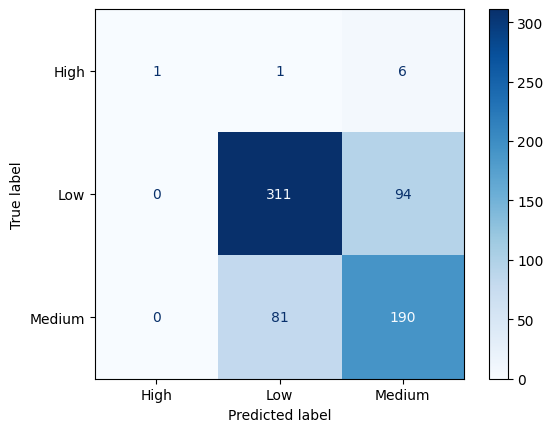

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred, display_labels=target_encoder.classes_, cmap="Blues")

In [34]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
10,YEAR_BUILT_027,0.079859
4,LAT_016,0.057351
5,LONG_017,0.043787
33,MAX_SPAN_LEN_MT_048,0.040030
67,DECK_AREA,0.037448
34,STRUCTURE_LEN_MT_049,0.035554
64,FUTURE_ADT_114,0.032824
13,ADT_029,0.032702
3,KILOPOINT_011,0.032450
15,APPR_WIDTH_MT_032,0.032155


In [35]:
import joblib

joblib.dump(rf, "../models/random_forest.pkl")
joblib.dump(target_encoder, "../models/label_encoder.pkl")

['../models/label_encoder.pkl']